# Random Forest — Concept, Implementation & Evaluation


## 1. The Problem with a Single Decision Tree

We learned that Decision Trees are powerful and interpretable — but they have serious weaknesses:

1. **High Variance (Instability)** — Small changes in the training data can produce a completely different tree. If you remove a few data points or add some noise, the root node might change, and the entire tree structure shifts. This instability makes single trees unreliable.

2. **Overfitting** — Even with pruning, a single tree can memorize patterns specific to the training data.

3. **Greedy Algorithm** — The tree makes the best split at each node without considering future consequences. This locally optimal approach does not guarantee a globally optimal tree.

What if, instead of relying on **one** tree, we built **hundreds** of trees and let them **vote**? Each individual tree might make mistakes, but if we aggregate their predictions, the errors tend to cancel out. This is the fundamental insight behind **Random Forests**.

## 2. What is a Random Forest?

A Random Forest is an **ensemble** of Decision Trees. The word "ensemble" means a collection working together — like an orchestra where many instruments combine to produce something richer than any single instrument could alone.

Here is how it works:

### Step 1: Bootstrap Sampling (Bagging)

For each tree, we create a **bootstrap sample** — a random sample of the training data, drawn **with replacement**. This means some training samples may appear multiple times in a tree's training set, while others are left out entirely.

If we have 1000 training samples, each tree gets a bootstrap sample of 1000 (same size), but roughly 63% of the original samples will be included (some multiple times) and roughly 37% will be left out. The left-out samples are called **Out-of-Bag (OOB)** samples — they serve as a free validation set.

### Step 2: Random Feature Selection

At each split in each tree, instead of considering **all** features, we randomly select a **subset** of features and pick the best split from that subset only. For classification, the default is $\sqrt{n_{features}}$.

Why? If we use all features, the same dominant feature (like `worst radius` in our cancer dataset) would appear at the root of every tree, making all trees very similar. By forcing each tree to consider different feature subsets, we ensure **diversity** — each tree sees the problem from a slightly different angle.

### Step 3: Aggregation (Voting)

For classification, each tree makes a prediction, and the final prediction is determined by **majority vote** — the class that gets the most votes wins. For regression, it is the **average** of all predictions.

### Why Does This Work?

The magic is in the **diversity**. Because each tree is trained on different data (bootstrap) and considers different features (random subspace), the trees make **different errors**. When we average many diverse, somewhat-incorrect predictions, the individual errors cancel out, and the ensemble is more accurate and stable than any single tree.

This is sometimes called the **"wisdom of crowds"** — a group of diverse decision-makers often outperforms any individual expert.

## 3. Key Hyperparameters

Random Forest has several hyperparameters. Here are the most important ones:

- **`n_estimators`** — The number of trees in the forest. More trees = better performance (diminishing returns after a point). Typical values: 100-500. More trees never cause overfitting but increase training time.

- **`max_depth`** — Maximum depth of each tree. Unlike a single Decision Tree, Random Forest trees are often left unrestricted (deep) because the ensemble averaging handles the overfitting. But limiting depth can speed up training.

- **`max_features`** — Number of features to consider at each split. Default is `'sqrt'` for classification ($\sqrt{n_{features}}$). Lower values = more diversity = less overfitting but potentially higher bias.

- **`min_samples_split`** — Minimum samples to split a node (same as single tree).

- **`min_samples_leaf`** — Minimum samples in a leaf (same as single tree).

- **`bootstrap`** — Whether to use bootstrap sampling. Default is True. Set to False for a "pasting" approach (sampling without replacement).

- **`oob_score`** — Whether to use Out-of-Bag samples for validation. Set to True to get a free accuracy estimate without needing a separate validation set.

The most impactful hyperparameters are `n_estimators` and `max_features`. Start with the defaults and tune from there.

## 4. Random Forest vs Single Decision Tree

| Aspect | Single Decision Tree | Random Forest |
|--------|---------------------|---------------|
| **Overfitting** | Very prone | Much more resistant |
| **Stability** | Unstable (high variance) | Stable (averaged) |
| **Interpretability** | Fully readable | Black box (many trees) |
| **Feature Importance** | Yes | Yes (more reliable due to averaging) |
| **Training Speed** | Fast | Slower (many trees) |
| **Accuracy** | Lower | Higher (usually) |
| **Feature Scaling** | Not needed | Not needed |

## 5. Setup and Imports

**Task:** Import all required libraries.

In [1]:
# Import numpy, pandas, matplotlib.pyplot, seaborn

# From sklearn.model_selection import train_test_split

# From sklearn.ensemble import RandomForestClassifier

# From sklearn.tree import DecisionTreeClassifier

# From sklearn.metrics import (accuracy_score, classification_report,
#                               confusion_matrix, roc_curve, roc_auc_score)

# From sklearn.datasets import load_breast_cancer

# Set seaborn style and random seed (42)


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_curve, roc_auc_score)
from sklearn.datasets import load_breast_cancer

## 6. Loading and Preparing the Data

We continue with the Breast Cancer dataset. Like Decision Trees, Random Forests do **not** require feature scaling.

**Task:** Load the data and split into train/test.

In [3]:
# Load the Breast Cancer dataset (as_frame=True)

# Separate X and y

# Split into train/test (test_size=0.2, random_state=42, stratify=y)

# Print shapes and class distribution
cancer = load_breast_cancer(as_frame = True)

X = cancer.data
y = cancer.target


X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    random_state=42,
    stratify=y
)


print(f"Breast Cancer Dataset loaded")
print(f"  Training: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"  Test:     {X_test.shape[0]} samples")
print(f"  Classes:  0=Malignant ({(y_train==0).sum()} train), 1=Benign ({(y_train==1).sum()} train)")
print(f"\n  No feature scaling needed for Random Forest!")


Breast Cancer Dataset loaded
  Training: 426 samples, 30 features
  Test:     143 samples
  Classes:  0=Malignant (159 train), 1=Benign (267 train)

  No feature scaling needed for Random Forest!


## 7. Building the Random Forest

Let us start with a Random Forest using 100 trees and default settings. We also enable `oob_score=True` to get an Out-of-Bag accuracy estimate — this is a free validation metric that comes from the bootstrap process.

**Task:** Train a Random Forest and examine its properties.

In [4]:
# Create RandomForestClassifier with:
#   n_estimators=100, random_state=42, oob_score=True

# Fit on X_train, y_train

# Print:
#   Number of trees: model.n_estimators
#   Max features per split: model.max_features_
#   OOB Score: model.oob_score_
#   Training accuracy
#   Test accuracy

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, oob_score=True) 
rf_model.fit(X_train, y_train)


train_acc = accuracy_score(y_train, rf_model.predict(X_train))
test_acc = accuracy_score(y_test, rf_model.predict(X_test))


print("=" * 55)
print("  RANDOM FOREST — 100 Trees")
print("=" * 55)
print(f"  Number of Trees:      {rf_model.n_estimators}")
print(f"  Max Features/Split:   {rf_model.max_features} → {int(np.sqrt(X_train.shape[1]))} features")
print(f"  OOB Score:            {rf_model.oob_score_:.4f}")
print(f"  Training Accuracy:    {train_acc:.4f}")
print(f"  Test Accuracy:        {test_acc:.4f}")
print(f"  Gap:                  {train_acc - test_acc:.4f}")
print("=" * 55)


  RANDOM FOREST — 100 Trees
  Number of Trees:      100
  Max Features/Split:   sqrt → 5 features
  OOB Score:            0.9624
  Training Accuracy:    1.0000
  Test Accuracy:        0.9580
  Gap:                  0.0420


**What to observe:** The OOB score is an accuracy estimate from samples that each tree did NOT see during training — it is like a built-in cross-validation. It should be close to the test accuracy. Also compare the train-test gap with the single Decision Tree from Day 51 — Random Forest should have a much smaller gap.


## 8. Single Tree vs Random Forest — Direct Comparison

Let us train both a single Decision Tree and a Random Forest and compare them side by side. This is the most direct way to see the benefit of ensembling.

**Task:** Train both models and compare.

In [5]:
# Train a single DecisionTreeClassifier(random_state=42) — unrestricted
# Train a RandomForestClassifier(n_estimators=100, random_state=42)
# For each model, compute: train accuracy, test accuracy, gap
# Display comparison in a neat table
# Include: Model, Train Accuracy, Test Accuracy, Gap

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_train = accuracy_score(y_train, dt_model.predict(X_train))
dt_test = accuracy_score(y_test, dt_model.predict(X_test))

rf_train = train_acc
rf_test = test_acc


print("=" * 60)
print("  SINGLE TREE vs RANDOM FOREST")
print("=" * 60)
print(f"  {'Model':<25} {'Train Acc':>10} {'Test Acc':>10} {'Gap':>8}")
print(f"  {'-'*25} {'-'*10} {'-'*10} {'-'*8}")
print(f"  {'Single Decision Tree':<25} {dt_train:>10.4f} {dt_test:>10.4f} {dt_train-dt_test:>8.4f}")
print(f"  {'Random Forest (100)':<25} {rf_train:>10.4f} {rf_test:>10.4f} {rf_train-rf_test:>8.4f}")
print("=" * 60)

improvement = rf_test - dt_test
print(f"\n  Test accuracy improvement: +{improvement:.4f} ({improvement:.1%})")
print(f"  Gap reduction: {(dt_train-dt_test) - (rf_train-rf_test):.4f}")


  SINGLE TREE vs RANDOM FOREST
  Model                      Train Acc   Test Acc      Gap
  ------------------------- ---------- ---------- --------
  Single Decision Tree          1.0000     0.9231   0.0769
  Random Forest (100)           1.0000     0.9580   0.0420

  Test accuracy improvement: +0.0350 (3.5%)
  Gap reduction: 0.0350


**What to observe:** The single tree likely has 100% training accuracy (memorized) but lower test accuracy. The Random Forest may also have very high training accuracy, but its test accuracy should be significantly better than the single tree. The ensemble averaging reduces overfitting without needing explicit pruning.


## 9. Effect of Number of Trees (n_estimators)

How many trees do we need? Let us experiment by training Random Forests with different numbers of trees and tracking the test accuracy. We expect to see accuracy improve as we add trees, then plateau once we have "enough."

**Task:** Sweep n_estimators from 1 to 300 and plot the accuracy curve.

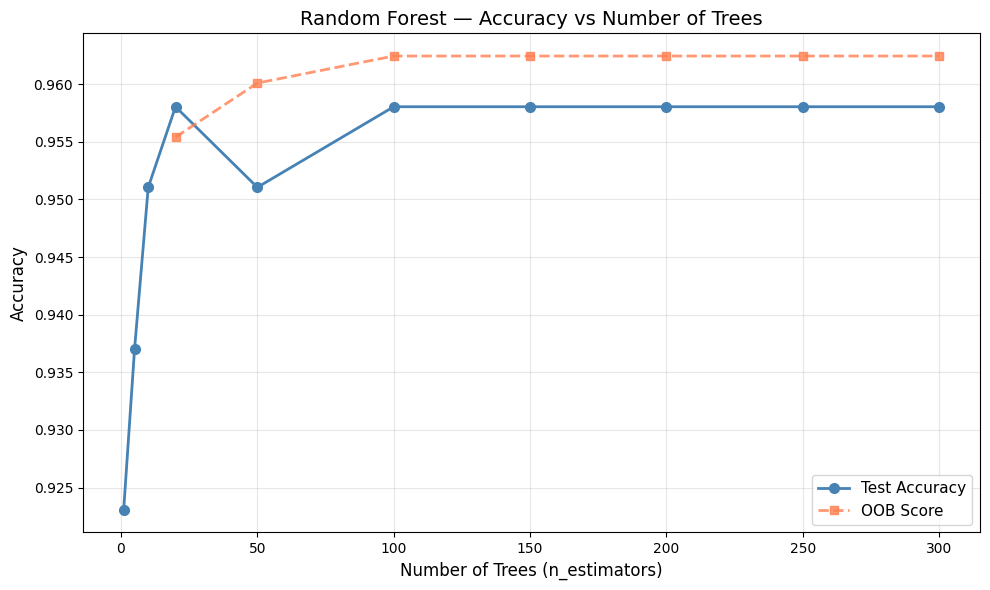

Best test accuracy: 0.9580 at 20 trees
Accuracy with 100 trees: 0.9580
Accuracy with 300 trees: 0.9580


In [8]:
# Define a range: n_trees_list = [1, 5, 10, 20, 50, 100, 150, 200, 250, 300]

# For each n_trees:
#   Fit RandomForestClassifier(n_estimators=n_trees, random_state=42)
#   Compute test accuracy
#   Store in a list

# Plot n_trees vs test accuracy with figsize=(10, 6)
# Use markers and lines
# Add title: 'Random Forest — Test Accuracy vs Number of Trees'
# Add labels
# Show the plot

# Print the optimal number of trees and its accuracy
n_trees_list = [1, 5, 10, 20, 50, 100, 150, 200, 250, 300]
test_accs = []
oob_scores = []

for n in n_trees_list:
    rf = RandomForestClassifier(
            n_estimators=n,
            random_state=42,
            oob_score = (n>=20),
            n_jobs = -1
        
        )
    rf.fit(X_train, y_train)
    
    test_accs.append(accuracy_score(y_test, rf.predict(X_test)))
    oob_scores.append(rf.oob_score_ if n >=20 else np.nan)


plt.figure(figsize=(10, 6))
plt.plot(n_trees_list, test_accs, 'o-', color='steelblue', linewidth=2,
         markersize=7, label='Test Accuracy')
plt.plot(n_trees_list, oob_scores, 's--', color='coral', linewidth=2,
         markersize=6, alpha=0.8, label='OOB Score')

plt.title('Random Forest — Accuracy vs Number of Trees', fontsize=14)
plt.xlabel('Number of Trees (n_estimators)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_idx = np.argmax(test_accs)
print(f"Best test accuracy: {test_accs[best_idx]:.4f} at {n_trees_list[best_idx]} trees")
print(f"Accuracy with 100 trees: {test_accs[n_trees_list.index(100)]:.4f}")
print(f"Accuracy with 300 trees: {test_accs[-1]:.4f}")


**What to observe:** With just 1 tree, it is a regular Decision Tree. Accuracy jumps dramatically as we add the first 10-50 trees. After that, the curve flattens — adding more trees brings diminishing returns. The good news: **more trees never hurt** (they just slow down training). A common practice is to start with 100-200 and increase if needed.


## 10. Feature Importance

Random Forest feature importance is more reliable than a single tree's importance because it is **averaged across all trees**. In a single tree, importance depends on which tree happened to grow. In a Random Forest, each tree considers different bootstrap samples and feature subsets, so the averaged importance is a more stable and trustworthy estimate.

**Task:** Extract and visualize feature importances.

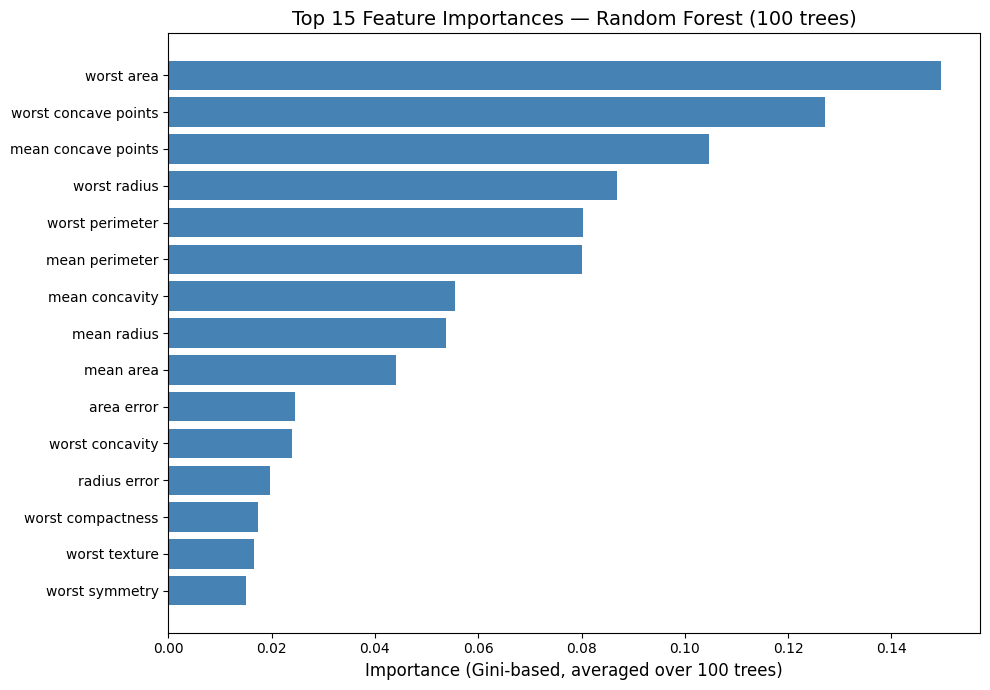


Top 5 most important features:
  worst area                    : 0.1497
  worst concave points          : 0.1272
  mean concave points           : 0.1046
  worst radius                  : 0.0870
  worst perimeter               : 0.0803

Features with zero importance: 0 / 30
Features with <1% importance: 11 / 30


In [9]:
# Access model.feature_importances_

# Create a DataFrame with 'Feature' and 'Importance'

# Sort by importance descending, select top 15

# Create a horizontal bar chart with figsize=(10, 7)

# Add title: 'Top 15 Feature Importances — Random Forest (100 trees)'
# Add x-label: 'Importance'
# Show the plot

# Print the number of features with zero importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values("Importance", ascending=True).tail(15)





plt.figure(figsize=(10, 7))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.title('Top 15 Feature Importances — Random Forest (100 trees)', fontsize=14)
plt.xlabel('Importance (Gini-based, averaged over 100 trees)', fontsize=12)
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
top5 = importance_df.tail(5).iloc[::-1]
for _, row in top5.iterrows():
    print(f"  {row['Feature']:30s}: {row['Importance']:.4f}")

n_zero = (rf_model.feature_importances_ == 0).sum()
n_low = (rf_model.feature_importances_ < 0.01).sum()
print(f"\nFeatures with zero importance: {n_zero} / {len(X.columns)}")
print(f"Features with <1% importance: {n_low} / {len(X.columns)}")

**What to observe:** Compare this with the single Decision Tree importance from Day 51. The Random Forest importance should be "smoother" — more features have non-zero importance because different trees use different features. The top features should be similar, but the relative rankings may shift because the ensemble explores more feature combinations.


## 11. Model Evaluation

### 11.1 Confusion Matrix

**Task:** Compute and visualize the confusion matrix.

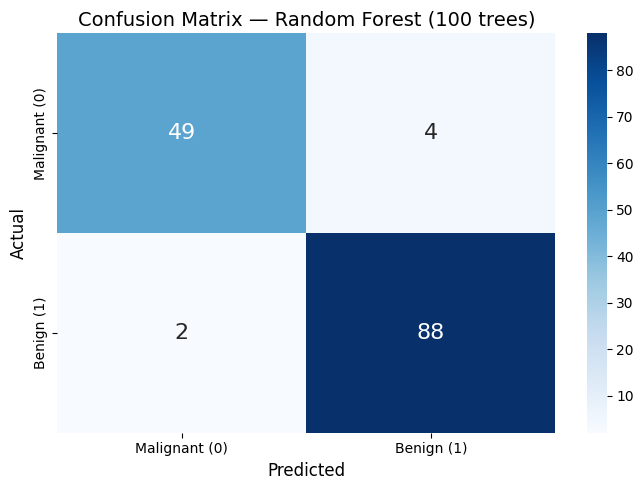

TN: 49 | FP: 4 | FN: 2 | TP: 88


In [10]:
# Predict on test set

# Compute confusion matrix

# Visualize with sns.heatmap, figsize=(7, 5)
# Labels: ['Malignant (0)', 'Benign (1)']
# Add title: 'Confusion Matrix — Random Forest'
# Show the plot

y_pred  = rf_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant (0)', 'Benign (1)'],
            yticklabels=['Malignant (0)', 'Benign (1)'],
            annot_kws={'size': 16})
plt.title('Confusion Matrix — Random Forest (100 trees)', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TN: {tn} | FP: {fp} | FN: {fn} | TP: {tp}")


### 11.2 Classification Report

**Task:** Print the full classification report.

In [11]:
# Print classification_report with target_names
print(classification_report(y_test, y_pred, target_names=['Malignant (0)', 'Benign (1)']))


               precision    recall  f1-score   support

Malignant (0)       0.96      0.92      0.94        53
   Benign (1)       0.96      0.98      0.97        90

     accuracy                           0.96       143
    macro avg       0.96      0.95      0.95       143
 weighted avg       0.96      0.96      0.96       143



### 11.3 ROC Curve and AUC

Random Forest outputs probabilities by averaging the predicted probabilities from all trees. This tends to produce well-calibrated, smooth probability estimates.

**Task:** Plot the ROC curve and compute AUC.

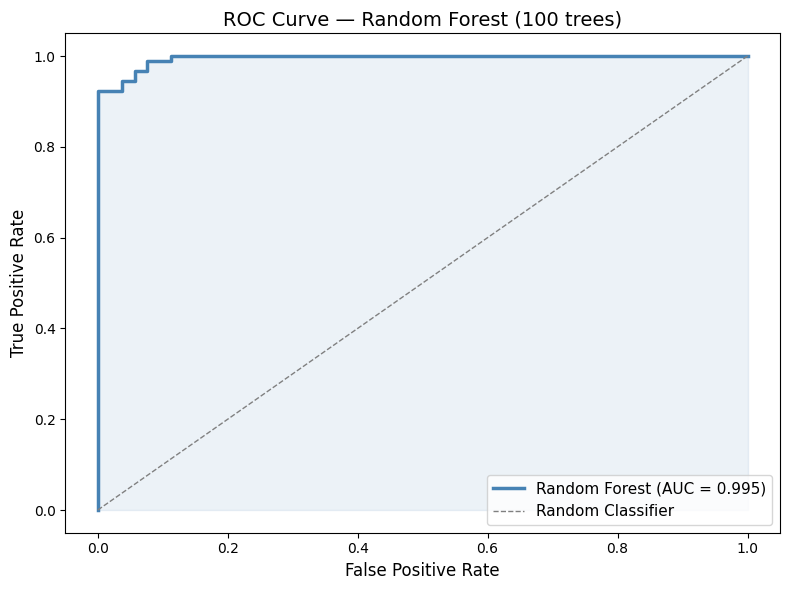

AUC Score: 0.9950


In [12]:
# Get predicted probabilities for class 1

# Compute ROC curve and AUC

# Plot with figsize=(8, 6)
# Include AUC in the label
# Plot diagonal baseline
# Add title: 'ROC Curve — Random Forest'
# Show the plot
y_prob = rf_model.predict_proba(X_test)[:, 1]

fpr, tpr , thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', linewidth=2.5,
         label=f'Random Forest (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', linewidth=1,
         label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='steelblue')

plt.title('ROC Curve — Random Forest (100 trees)', fontsize=14)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(fontsize=11, loc='lower right')
plt.tight_layout()
plt.show()

print(f"AUC Score: {auc:.4f}")

**What to observe:** The ROC curve should be smoother than the single Decision Tree's staircase-shaped curve (Day 51). This is because the averaged probabilities from 100 trees produce a more continuous probability distribution.


## 12. Hyperparameter Tuning — max_depth and max_features

While Random Forests are less sensitive to hyperparameters than single trees, tuning can still improve performance. Let us explore how `max_depth` and `max_features` affect the model.

### 12.1 Effect of max_depth

**Task:** Sweep max_depth and plot accuracy.

In [13]:
# Try max_depth values: [2, 3, 5, 7, 10, 15, 20, None]
# None means unrestricted (default)

# For each depth:
#   Fit RandomForestClassifier(n_estimators=100, max_depth=depth, random_state=42)
#   Compute train and test accuracy

# Display results in a table
# Include: max_depth, Train Accuracy, Test Accuracy, Gap


depth_values = [2, 3, 5, 7, 10, 15, 20, None]
print(f"{'max_depth':<12} {'Train Acc':>10} {'Test Acc':>10} {'Gap':>8} {'OOB Score':>10}")
print("-" * 54)

for depth in depth_values:
    rf = RandomForestClassifier(n_estimators=100, max_depth=depth, random_state=42, oob_score=True)
    rf.fit(X_train, y_train)
    
    tr_acc = accuracy_score(y_train, rf.predict(X_train))
    te_acc = accuracy_score(y_test, rf.predict(X_test))
    gap = tr_acc - te_acc
    
    depth_str = str(depth) if depth is not None else 'None'
    print(f"{depth_str:<12} {tr_acc:>10.4f} {te_acc:>10.4f} {gap:>8.4f} {rf.oob_score_:>10.4f}")


max_depth     Train Acc   Test Acc      Gap  OOB Score
------------------------------------------------------
2                0.9624     0.9371   0.0254     0.9390
3                0.9836     0.9510   0.0325     0.9577
5                0.9930     0.9510   0.0419     0.9531
7                0.9977     0.9580   0.0396     0.9601
10               1.0000     0.9580   0.0420     0.9624
15               1.0000     0.9580   0.0420     0.9624
20               1.0000     0.9580   0.0420     0.9624
None             1.0000     0.9580   0.0420     0.9624


**What to observe:** Unlike a single tree, a Random Forest with unrestricted depth (None) often performs well because the ensemble averaging handles the overfitting. However, shallower trees can sometimes improve test accuracy slightly and definitely speed up training. The sweet spot depends on the dataset.

### 12.2 Effect of max_features

**Task:** Try different max_features settings.

In [14]:
# Try max_features values: ['sqrt', 'log2', 5, 10, 15, None]
# None means all features (no randomness in feature selection)

# For each setting:
#   Fit RandomForestClassifier(n_estimators=100, max_features=mf, random_state=42)
#   Compute test accuracy and OOB score (set oob_score=True)

# Display results in a table

# Different max_features settings
mf_values = ['sqrt', 'log2', 5, 10, 15, None]
mf_labels = ['sqrt (~5)', 'log2 (~5)', '5', '10', '15', 'All (30)']

print(f"{'max_features':<15} {'Actual':>10} {'Test Acc':>10} {'OOB Score':>10}")
print("-" * 50)

for mf, label in zip(mf_values, mf_labels):
    rf = RandomForestClassifier(
        n_estimators=100,
        max_features=mf,
        random_state=42,
        oob_score=True,
        n_jobs=-1  # use all CPU cores (faster)
    )

    rf.fit(X_train, y_train)

    # Predictions & accuracy
    y_pred = rf.predict(X_test)
    te_acc = accuracy_score(y_test, y_pred)

    # Handle None safely for printing
    actual_mf = rf.max_features if rf.max_features is not None else "All"

    print(f"{label:<15} {str(actual_mf):>10} {te_acc:>10.4f} {rf.oob_score_:>10.4f}")

max_features        Actual   Test Acc  OOB Score
--------------------------------------------------
sqrt (~5)             sqrt     0.9580     0.9624
log2 (~5)             log2     0.9580     0.9460
5                        5     0.9580     0.9624
10                      10     0.9580     0.9507
15                      15     0.9580     0.9601
All (30)               All     0.9510     0.9624


**What to observe:** Using all features (`None`) removes the randomness that makes Random Forest work — the trees become too similar. Using too few features adds too much randomness. The default `'sqrt'` is usually a good starting point. Notice how OOB score tracks test accuracy — it is a reliable proxy.



## 13. Grand Comparison — All Models So Far

Let us bring together every classifier we have learned — Logistic Regression, SVM, Decision Tree, and Random Forest — for a final head-to-head comparison.

**Task:** Train all four models and compare.

In [15]:
# Import LogisticRegression, SVC, StandardScaler

# Scale features for LR and SVM

# Train all four models:
#   Logistic Regression (on scaled data)
#   SVM RBF (on scaled data)
#   Decision Tree max_depth=5 (on unscaled data)
#   Random Forest n_estimators=100 (on unscaled data)

# For each: compute test accuracy, AUC

# Display comparison table

# Print which model won on each metric


from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

all_models = {
    'Logistic Regression': (LogisticRegression(random_state=42, max_iter=5000), X_train_sc, X_test_sc),
    'SVM (RBF)': (SVC(kernel='rbf', probability=True, random_state=42), X_train_sc, X_test_sc),
    'Decision Tree (d=5)': (DecisionTreeClassifier(max_depth=5, random_state=42), X_train, X_test),
    'Random Forest (100)': (RandomForestClassifier(n_estimators=100, random_state=42), X_train, X_test)
}

grand_results = []

for name, (model, X_tr, X_te) in all_models.items():
    model.fit(X_tr, y_train)
    y_p = model.predict(X_te)
    y_pr = model.predict_proba(X_te)[:, 1]

    acc = accuracy_score(y_test, y_p)
    auc_s = roc_auc_score(y_test, y_pr)

    grand_results.append({
        'Model': name,
        'Test Accuracy': round(acc, 4),
        'AUC Score': round(auc_s, 4)
    })

grand_df = pd.DataFrame(grand_results).sort_values('Test Accuracy', ascending=False)

print("=" * 58)
print("  GRAND COMPARISON — All Classifiers")
print("=" * 58)
print(grand_df.to_string(index=False))
print("=" * 58)

best_model = grand_df.iloc[0]
print(f"\n  Best by Accuracy: {best_model['Model']} ({best_model['Test Accuracy']})")
best_auc = grand_df.sort_values('AUC Score', ascending=False).iloc[0]
print(f"  Best by AUC:      {best_auc['Model']} ({best_auc['AUC Score']})")

  GRAND COMPARISON — All Classifiers
              Model  Test Accuracy  AUC Score
Logistic Regression         0.9860     0.9977
          SVM (RBF)         0.9790     0.9969
Random Forest (100)         0.9580     0.9950
Decision Tree (d=5)         0.9371     0.9186

  Best by Accuracy: Logistic Regression (0.986)
  Best by AUC:      Logistic Regression (0.9977)


**What to observe:** Random Forest should be competitive with or better than all other models. On this dataset, the differences may be small because the data is relatively clean and linearly separable. On messier, non-linear datasets, the advantage of Random Forest becomes much more pronounced.



## 14. When to Use Random Forest

**Use Random Forest when:**
- You want a strong baseline model that works well "out of the box" with minimal tuning
- You have tabular data (structured data with rows and columns)
- You want reliable feature importance estimates
- You need a model that handles missing values and mixed data types reasonably
- You do not need feature scaling

**Consider alternatives when:**
- Interpretability is critical → use a single Decision Tree or Logistic Regression
- The dataset is very large (millions of rows) → Random Forest can be slow; consider gradient boosting (XGBoost, LightGBM)
- You need calibrated probability outputs → Logistic Regression is better calibrated by default
- The data is linearly separable → Logistic Regression or Linear SVM may suffice and be faster



## 15. Summary and Key Takeaways

**Core Concept:**
- Random Forest = ensemble of many Decision Trees
- Each tree is trained on a different bootstrap sample with a random subset of features at each split
- Final prediction is by majority vote (classification) or average (regression)
- Diversity between trees is the key — it makes the ensemble better than any individual tree

**How It Prevents Overfitting:**
- Bootstrap sampling → each tree sees different data
- Random feature selection → each tree considers different features
- Averaging → individual tree errors cancel out

**Key Hyperparameters:**

| Parameter | Default | Effect |
|-----------|---------|--------|
| `n_estimators` | 100 | More trees = better (diminishing returns). Never overfits. |
| `max_features` | `'sqrt'` | Controls tree diversity. Lower = more diverse. |
| `max_depth` | None | Limits tree complexity. Often left unrestricted. |
| `oob_score` | False | Set True for free validation estimate. |

**Strengths:**
- Excellent accuracy on tabular data
- Resistant to overfitting
- No feature scaling needed
- Reliable feature importance
- Works well with default settings

**Weaknesses:**
- Less interpretable than a single tree
- Slower to train (many trees)
- Can be slow for prediction with very many trees
- Generally outperformed by gradient boosting on well-tuned benchmarks

**What comes next:** Gradient Boosting (XGBoost, LightGBM) — another ensemble approach that builds trees sequentially, each one correcting the errors of the previous ones.